# Healthcare Employee Attrition Analysis
**Kevin Serizawa | Data In Motion**

This notebook examines which employee characteristics are associated with attrition in the supplied Watson Healthcare dataset. It preserves the original Pandas analysis, organizes the milestone questions, and regenerates the final charts from calculated values.

**Headline finding:** 199 of 1,676 employees left (11.87%). Among 48 employees aged ≤25, with ≤1 year at the company and monthly income <$3,000, 32 left (66.67%). These are observed associations, not causal effects or predictions.

## How to run
Use an authorized copy of `watson_healthcare_modified2.csv`, supplied directly by Data In Motion. Place it in `data/` or beside this notebook. In Colab, the loading cell offers an upload prompt if the file is absent. Run all cells in order. A fresh runtime requires the CSV again. Charts are saved to `figures/` before display.

The raw dataset is not included because redistribution terms have not been confirmed. Saved notebook outputs contain aggregate results, not employee-level previews.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

file_name = "watson_healthcare_modified2.csv"
candidates = [Path("data") / file_name, Path(file_name)]
file_path = next((p for p in candidates if p.is_file()), None)
if file_path is None:
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(f"Place {file_name} in data/ or beside the notebook.")
    uploaded = files.upload()
    file_path = Path(file_name)
    if not file_path.is_file():
        raise FileNotFoundError(f"Upload the file with the exact name {file_name}.")

df = pd.read_csv(file_path)
figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)

## Data validation
Check the population, identifiers, missing values and duplicate rows before calculating rates. The supplied data needs no missing-value imputation or duplicate removal. `Admin` and `Administrative` remain separate because their equivalence has not been confirmed. Constant columns do not explain differences in attrition.

In [2]:
quality = pd.Series({
    "Employee rows": len(df), "Columns": df.shape[1],
    "Unique employee IDs": df["EmployeeID"].nunique(),
    "Missing values": int(df.isna().sum().sum()),
    "Duplicate rows": int(df.duplicated().sum()),
    "Duplicate employee IDs": int(df["EmployeeID"].duplicated().sum()),
})
display(quality.to_frame("Result"))
display(pd.DataFrame({"Data type": df.dtypes.astype(str), "Missing": df.isna().sum()}))
constant_columns = df.columns[df.nunique(dropna=False).eq(1)].tolist()
print("Constant columns:", constant_columns)
print("Attrition labels:", sorted(df["Attrition"].unique()))
assert set(df["Attrition"].unique()) == {"Yes", "No"}

,Result
Employee rows,1676
Columns,35
Unique employee IDs,1676
Missing values,0
Duplicate rows,0
Duplicate employee IDs,0


,Data type,Missing
EmployeeID,int64,0
Age,int64,0
Attrition,str,0
BusinessTravel,str,0
DailyRate,int64,0
Department,str,0
DistanceFromHome,int64,0
Education,int64,0
EducationField,str,0
EmployeeCount,int64,0


Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
Attrition labels: ['No', 'Yes']


## 1. Overall attrition

Each row represents one employee. The denominator is the complete dataset, not just departures.

In [3]:
df["Attrition"].value_counts()

Attrition
No     1477
Yes     199
Name: count, dtype: int64

In [4]:
attrition_rate = (
    df["Attrition"].value_counts(normalize=True)["Yes"] * 100
)

print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 11.87%


In [5]:
total_employees = len(df)
departures = int(df["Attrition"].eq("Yes").sum())
overall_rate_pct = departures / total_employees * 100
display(pd.Series({"Total Employees": total_employees, "Employees Who Left": departures}).to_frame("Count"))
print(f"Overall attrition: {overall_rate_pct:.2f}%")

,Count
Total Employees,1676
Employees Who Left,199


Overall attrition: 11.87%


## 2. Department

Compare within-department rates alongside counts because department sizes differ. Display formatting preserves numeric values.

In [6]:
df["Department"].value_counts()

Department
Maternity     796
Cardiology    531
Neurology     349
Name: count, dtype: int64

In [7]:
pd.crosstab(df["Department"], df["Attrition"])

Attrition,No,Yes
Department,,
Cardiology,457,74
Maternity,698,98
Neurology,322,27


In [8]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition.style.format("{:.2f}%")

Attrition,No,Yes
Department,,
Cardiology,86.06%,13.94%
Maternity,87.69%,12.31%
Neurology,92.26%,7.74%


## 3. Age demographics

Age groups use right-closed bins: the first interval (17, 25] includes ages 18–25. Leavers have a lower mean age, but group patterns do not establish causation.

In [9]:
df.groupby("Attrition")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1477.0,37.670278,8.865543,18.0,31.0,36.0,44.0,60.0
Yes,199.0,30.899497,8.860875,18.0,25.5,29.0,34.0,58.0


In [10]:
bins = [17, 25, 35, 45, 55, 60]
labels = ["18-25", "26-35", "36-45", "46-55", "56-60"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

age_attrition = pd.crosstab(
    df["AgeGroup"],
    df["Attrition"],
    normalize="index"
) * 100

age_attrition.style.format("{:.2f}%")

Attrition,No,Yes
AgeGroup,,
18-25,64.03%,35.97%
26-35,84.29%,15.71%
36-45,95.47%,4.53%
46-55,95.80%,4.20%
56-60,90.20%,9.80%


## 4. Gender and education

These are descriptive comparisons, not statistical-significance tests. Small differences or a single low-rate education category should not be overstated.

In [11]:
gender_attrition = pd.crosstab(
    df["Gender"],
    df["Attrition"],
    normalize="index"
) * 100

gender_attrition.style.format("{:.2f}%")

Attrition,No,Yes
Gender,,
Female,87.32%,12.68%
Male,88.68%,11.32%


In [12]:
education_attrition = pd.crosstab(
    df["Education"],
    df["Attrition"],
    normalize="index"
) * 100

education_attrition.style.format("{:.2f}%")

Attrition,No,Yes
Education,,
1,86.22%,13.78%
2,89.13%,10.87%
3,86.41%,13.59%
4,89.49%,10.51%
5,98.21%,1.79%


In [13]:
df["Education"].value_counts().sort_index()

Education
1    196
2    322
3    655
4    447
5     56
Name: count, dtype: int64

In [14]:
pd.crosstab(df["Education"], df["Attrition"])

Attrition,No,Yes
Education,,
1,169,27
2,287,35
3,566,89
4,400,47
5,55,1


## 5. Job role

A high departure count may reflect a large employee population. The source labels Admin and Administrative are retained separately.

In [15]:
df["JobRole"].value_counts()

JobRole
Nurse             822
Other             534
Therapist         189
Administrative    115
Admin              16
Name: count, dtype: int64

In [16]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

jobrole_attrition.style.format("{:.2f}%")

Attrition,No,Yes
JobRole,,
Admin,100.00%,0.00%
Administrative,99.13%,0.87%
Nurse,86.98%,13.02%
Other,83.71%,16.29%
Therapist,97.88%,2.12%


In [17]:
jobrole_counts = pd.crosstab(
    df["JobRole"],
    df["Attrition"]
)

jobrole_counts

Attrition,No,Yes
JobRole,,
Admin,16,0
Administrative,114,1
Nurse,715,107
Other,447,87
Therapist,185,4


## 6. Job satisfaction

Attrition falls from 15.81% at Level 1 to 8.49% at Level 4. These coded levels describe ratings, not a measured causal effect.

In [18]:
df["JobSatisfaction"].value_counts().sort_index()

JobSatisfaction
1    329
2    310
3    507
4    530
Name: count, dtype: int64

In [19]:
jobsatisfaction_attrition = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

jobsatisfaction_attrition.style.format("{:.2f}%")

Attrition,No,Yes
JobSatisfaction,,
1,84.19%,15.81%
2,86.45%,13.55%
3,88.17%,11.83%
4,91.51%,8.49%


## 7. Distance from home

Grouping makes the 29 distance values easier to compare; it does not make individual-distance calculations inherently inaccurate. The 21–25-mile group peaks at 25.36%, then the rate falls to 12.00% at 26–29 miles.

In [20]:
df.groupby("Attrition")["DistanceFromHome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1477.0,8.905890,8.016494,1.0,2.0,7.0,13.0,29.0
Yes,199.0,11.567839,8.814254,1.0,3.0,9.0,19.5,29.0


In [21]:
bins = [0, 5, 10, 15, 20, 25, 29]
labels = ["1-5", "6-10", "11-15", "16-20", "21-25", "26-29"]

df["DistanceGroup"] = pd.cut(
    df["DistanceFromHome"],
    bins=bins,
    labels=labels
)

distance_attrition = pd.crosstab(
    df["DistanceGroup"],
    df["Attrition"],
    normalize="index"
) * 100

distance_attrition.style.format("{:.2f}%")

Attrition,No,Yes
DistanceGroup,,
1-5,90.71%,9.29%
6-10,89.73%,10.27%
11-15,85.71%,14.29%
16-20,85.31%,14.69%
21-25,74.64%,25.36%
26-29,88.00%,12.00%


In [22]:
df["DistanceGroup"].value_counts().sort_index()

DistanceGroup
1-5      721
6-10     448
11-15    126
16-20    143
21-25    138
26-29    100
Name: count, dtype: int64

## 8. Work-life balance: rate versus count

Level 1 has 24 departures among 90 employees (26.67%); Level 3 has 100 among 1,028 (9.73%). Rate describes the within-group proportion, while count describes departure volume. Level 4 rises to 12.14%, so the relationship is not consistently declining.

In [23]:
df["WorkLifeBalance"].value_counts().sort_index()

WorkLifeBalance
1      90
2     385
3    1028
4     173
Name: count, dtype: int64

In [24]:
worklife_attrition = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

worklife_attrition.style.format("{:.2f}%")

Attrition,No,Yes
WorkLifeBalance,,
1,73.33%,26.67%
2,85.97%,14.03%
3,90.27%,9.73%
4,87.86%,12.14%


In [25]:
pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"]
)

Attrition,No,Yes
WorkLifeBalance,,
1,66,24
2,331,54
3,928,100
4,152,21


## 9. Performance rating

Only ratings 3 and 4 occur in this dataset. Their attrition rates are close; this is not strong evidence of an explanatory relationship.

In [26]:
df["PerformanceRating"].value_counts().sort_index()

PerformanceRating
3    1424
4     252
Name: count, dtype: int64

In [27]:
performance_attrition = pd.crosstab(
    df["PerformanceRating"],
    df["Attrition"],
    normalize="index"
) * 100

performance_attrition.style.format("{:.2f}%")

Attrition,No,Yes
PerformanceRating,,
3,88.27%,11.73%
4,87.30%,12.70%


## 10. Monthly income

Income is grouped into non-overlapping ranges. Employees earning under $3,000 have 26.23% attrition. Income may also relate to age, role and tenure.

In [28]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1477.0,6852.301963,4810.634808,1051.0,3294.0,5204.0,8858.0,19999.0
Yes,199.0,4024.246231,3089.287935,1009.0,2304.5,2741.0,4782.0,19859.0


In [29]:
bins = [0, 2999, 4999, 6999, 9999, 14999, 20000]
labels = [
    "$1,000-$2,999",
    "$3,000-$4,999",
    "$5,000-$6,999",
    "$7,000-$9,999",
    "$10,000-$14,999",
    "$15,000-$20,000"
]

df["IncomeGroup"] = pd.cut(
    df["MonthlyIncome"],
    bins=bins,
    labels=labels
)

income_attrition = pd.crosstab(
    df["IncomeGroup"],
    df["Attrition"],
    normalize="index"
) * 100

income_attrition.style.format("{:.2f}%")

Attrition,No,Yes
IncomeGroup,,
"$1,000-$2,999",73.77%,26.23%
"$3,000-$4,999",91.28%,8.72%
"$5,000-$6,999",93.50%,6.50%
"$7,000-$9,999",92.31%,7.69%
"$10,000-$14,999",94.08%,5.92%
"$15,000-$20,000",98.72%,1.28%


In [30]:
df["IncomeGroup"].value_counts().sort_index()

IncomeGroup
$1,000-$2,999      446
$3,000-$4,999      413
$5,000-$6,999      323
$7,000-$9,999      169
$10,000-$14,999    169
$15,000-$20,000    156
Name: count, dtype: int64

## 11. Years at the company

The first bin starts at -1 so zero-tenure employees enter (-1, 1]. Attrition is 31.95% for 0–1 years and falls substantially with tenure; it rises slightly between the last two groups.

In [31]:
df.groupby("Attrition")["YearsAtCompany"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1477.0,7.484089,6.183775,0.0,3.0,6.0,10.0,40.0
Yes,199.0,3.688442,4.106341,0.0,1.0,2.0,5.0,31.0


In [32]:
bins = [-1, 1, 3, 5, 10, 20, 40]
labels = [
    "0-1 years",
    "2-3 years",
    "4-5 years",
    "6-10 years",
    "11-20 years",
    "21+ years"
]

df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=bins,
    labels=labels
)

tenure_attrition = pd.crosstab(
    df["TenureGroup"],
    df["Attrition"],
    normalize="index"
) * 100

tenure_attrition.style.format("{:.2f}%")

Attrition,No,Yes
TenureGroup,,
0-1 years,68.05%,31.95%
2-3 years,84.23%,15.77%
4-5 years,90.27%,9.73%
6-10 years,93.19%,6.81%
11-20 years,97.60%,2.40%
21+ years,97.37%,2.63%


In [33]:
df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-1 years      241
2-3 years      298
4-5 years      339
6-10 years     514
11-20 years    208
21+ years       76
Name: count, dtype: int64

## 12. Current role and promotion timing

Current-role tenure has a clearer downward pattern than promotion timing. Zero years since promotion should not be interpreted as proof that someone has never been promoted.

In [34]:
df.groupby("Attrition")[
    ["YearsSinceLastPromotion", "YearsInCurrentRole"]
].describe()

YearsSinceLastPromotion                                          \
                            count      mean       std  min  25%  50%  75%   
Attrition                                                                   
No                         1477.0  2.302640  3.296516  0.0  0.0  1.0  3.0   
Yes                         199.0  1.442211  2.563423  0.0  0.0  0.0  2.0   

                YearsInCurrentRole                                          \
            max              count      mean       std  min  25%  50%  75%   
Attrition                                                                    
No         15.0             1477.0  4.541638  3.658036  0.0  2.0  3.0  7.0   
Yes        14.0              199.0  2.211055  2.598694  0.0  0.0  2.0  3.0   

                 
            max  
Attrition        
No         18.0  
Yes        15.0

In [35]:
bins = [-1, 1, 3, 5, 10, 18]
labels = [
    "0-1 years",
    "2-3 years",
    "4-5 years",
    "6-10 years",
    "11+ years"
]

df["CurrentRoleGroup"] = pd.cut(
    df["YearsInCurrentRole"],
    bins=bins,
    labels=labels
)

role_years_attrition = pd.crosstab(
    df["CurrentRoleGroup"],
    df["Attrition"],
    normalize="index"
) * 100

role_years_attrition.style.format("{:.2f}%")

Attrition,No,Yes
CurrentRoleGroup,,
0-1 years,75.15%,24.85%
2-3 years,87.24%,12.76%
4-5 years,91.72%,8.28%
6-10 years,94.57%,5.43%
11+ years,98.88%,1.12%


In [36]:
df["CurrentRoleGroup"].value_counts().sort_index()

CurrentRoleGroup
0-1 years     334
2-3 years     580
4-5 years     157
6-10 years    516
11+ years      89
Name: count, dtype: int64

In [37]:
bins = [-1, 0, 2, 5, 10, 15]
labels = [
    "0 years",
    "1-2 years",
    "3-5 years",
    "6-10 years",
    "11+ years"
]

df["PromotionGroup"] = pd.cut(
    df["YearsSinceLastPromotion"],
    bins=bins,
    labels=labels
)

promotion_attrition = pd.crosstab(
    df["PromotionGroup"],
    df["Attrition"],
    normalize="index"
) * 100

promotion_attrition.style.format("{:.2f}%")

Attrition,No,Yes
PromotionGroup,,
0 years,83.94%,16.06%
1-2 years,89.12%,10.88%
3-5 years,94.97%,5.03%
6-10 years,90.12%,9.88%
11+ years,96.10%,3.90%


In [38]:
df["PromotionGroup"].value_counts().sort_index()

PromotionGroup
0 years       660
1-2 years     588
3-5 years     179
6-10 years    172
11+ years      77
Name: count, dtype: int64

## 13. Training frequency

TrainingTimesLastYear measures the number of training occasions, not training hours. The rates do not follow a consistently declining pattern.

In [39]:
df["TrainingTimesLastYear"].value_counts().sort_index()

TrainingTimesLastYear
0     61
1     84
2    611
3    567
4    143
5    137
6     73
Name: count, dtype: int64

In [40]:
training_attrition = pd.crosstab(
    df["TrainingTimesLastYear"],
    df["Attrition"],
    normalize="index"
) * 100

training_attrition.style.format("{:.2f}%")

Attrition,No,Yes
TrainingTimesLastYear,,
0,78.69%,21.31%
1,94.05%,5.95%
2,84.94%,15.06%
3,91.01%,8.99%
4,87.41%,12.59%
5,89.78%,10.22%
6,91.78%,8.22%


## 14. Career-development opportunities
The dataset does not directly measure the availability or quality of career-development opportunities. Role tenure, promotion timing and training frequency are available, but they do not establish whether employees had access to development programs.

## 15. Overlapping employee characteristics
First compare age and income by tenure. Then filter employees who meet all three conditions. Group averages do not imply that every new employee is young or lower-paid.

In [41]:
df.groupby("TenureGroup", observed=False)["Age"].agg(
    EmployeeCount="count",
    AverageAge="mean",
    MedianAge="median"
).round(2)

,EmployeeCount,AverageAge,MedianAge
TenureGroup,,,
0-1 years,241,34.16,34.0
2-3 years,298,34.76,33.0
4-5 years,339,36.64,35.0
6-10 years,514,36.96,35.0
11-20 years,208,39.63,38.0
21+ years,76,46.50,45.5


In [42]:
df.groupby("TenureGroup", observed=False)["MonthlyIncome"].agg(
    EmployeeCount="count",
    AverageIncome="mean",
    MedianIncome="median"
).round(2)

,EmployeeCount,AverageIncome,MedianIncome
TenureGroup,,,
0-1 years,241,4608.12,2856.0
2-3 years,298,4999.92,3685.5
4-5 years,339,5487.97,4325.0
6-10 years,514,6548.78,5593.5
11-20 years,208,9061.83,7969.0
21+ years,76,15918.26,17058.0


In [43]:
high_risk_group = df[
    (df["Age"] <= 25) &
    (df["YearsAtCompany"] <= 1) &
    (df["MonthlyIncome"] < 3000)
]

high_risk_group.shape[0]

48

In [44]:
high_risk_group["Attrition"].value_counts()

Attrition
Yes    32
No     16
Name: count, dtype: int64

In [45]:
high_risk_attrition_rate = (
    high_risk_group["Attrition"].eq("Yes").mean() * 100
)

print(f"High-Risk Group Attrition Rate: {high_risk_attrition_rate:.2f}%")

High-Risk Group Attrition Rate: 66.67%


In [46]:
high_risk_departure_share = (
    (high_risk_group["Attrition"] == "Yes").sum()
    / (df["Attrition"] == "Yes").sum()
) * 100

print(f"Share of All Departures: {high_risk_departure_share:.2f}%")

Share of All Departures: 16.08%


In [47]:
high_risk_group = df[
    (df["Age"] <= 25) &
    (df["YearsAtCompany"] <= 1) &
    (df["MonthlyIncome"] < 3000)
]

high_risk_attritioners = high_risk_group[
    high_risk_group["Attrition"] == "Yes"
]

print("High-Risk Employees:", len(high_risk_group))
print("High-Risk Attritioners:", len(high_risk_attritioners))

High-Risk Employees: 48
High-Risk Attritioners: 32


In [48]:
job_satisfaction = (
    high_risk_attritioners["JobSatisfaction"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

job_satisfaction.to_frame("Percentage").style.format("{:.2f}%")

,Percentage
JobSatisfaction,
1,25.00%
2,25.00%
3,18.75%
4,31.25%


In [49]:
work_life_balance = (
    high_risk_attritioners["WorkLifeBalance"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

work_life_balance.to_frame("Percentage").style.format("{:.2f}%")

,Percentage
WorkLifeBalance,
1,6.25%
2,18.75%
3,59.38%
4,15.62%


The two rating tables above describe the **32 high-risk employees who left**. They are distributions among leavers, not attrition rates by rating. They do not establish that poor satisfaction or work-life balance explains the 66.67% segment rate; a comparison with the 16 stayers would be needed.

### Broad groups and isolated-condition comparisons
The broad age, tenure and income groups overlap. An “only” group below meets one condition and explicitly excludes the other two. These comparisons are descriptive, not estimates controlling for all other factors.

In [50]:
young = df["Age"] <= 25
new_employee = df["YearsAtCompany"] <= 1
lower_income = df["MonthlyIncome"] < 3000

def segment_summary(mask, label):
    subset = df.loc[mask]
    count = len(subset)
    left = int(subset["Attrition"].eq("Yes").sum())
    return {"Segment": label, "Employees": count, "Departures": left,
            "Attrition (%)": left / count * 100 if count else np.nan}

broad_segments = pd.DataFrame([
    segment_summary(young, "Age 18–25"),
    segment_summary(new_employee, "Tenure 0–1 years"),
    segment_summary(lower_income, "Income <$3,000"),
    segment_summary(young & new_employee & lower_income, "All three"),
]).set_index("Segment")
display(broad_segments.style.format({"Attrition (%)": "{:.2f}%"}))

isolated_segments = pd.DataFrame([
    segment_summary(young & ~new_employee & ~lower_income, "Age only"),
    segment_summary(~young & new_employee & ~lower_income, "Tenure only"),
    segment_summary(~young & ~new_employee & lower_income, "Income only"),
    segment_summary(young & new_employee & lower_income, "All three"),
]).set_index("Segment")
display(isolated_segments.style.format({"Attrition (%)": "{:.2f}%"}))

,Employees,Departures,Attrition (%)
Segment,,,
Age 18–25,139,50,35.97%
Tenure 0–1 years,241,77,31.95%
"Income <$3,000",446,117,26.23%
All three,48,32,66.67%


,Employees,Departures,Attrition (%)
Segment,,,
Age only,49,7,14.29%
Tenure only,105,15,14.29%
Income only,270,46,17.04%
All three,48,32,66.67%


The isolated-condition rates are 14.29%, 14.29% and 17.04%, compared with 66.67% for the intersection. These four rows are not a complete partition of the workforce: employees meeting two conditions or none are omitted. The original partial-exclusion checks are also retained below.

In [51]:
partial_exclusions = pd.DataFrame([
    segment_summary(young & ~new_employee, "Age ≤25 and tenure >1"),
    segment_summary(~young & new_employee, "Age >25 and tenure ≤1"),
    segment_summary(young & ~lower_income, "Age ≤25 and income ≥$3,000"),
    segment_summary(new_employee & ~lower_income, "Tenure ≤1 and income ≥$3,000"),
]).set_index("Segment")
display(partial_exclusions.style.format({"Attrition (%)": "{:.2f}%"}))

,Employees,Departures,Attrition (%)
Segment,,,
Age ≤25 and tenure >1,90,17,18.89%
Age >25 and tenure ≤1,192,44,22.92%
"Age ≤25 and income ≥$3,000",50,8,16.00%
"Tenure ≤1 and income ≥$3,000",106,16,15.09%


## Presentation charts
The original pastel-red, burgundy and gray styling is retained in simplified plotting code. Every bar and baseline below comes from computed results. The overlap chart uses broad groups, not the isolated-condition comparison. Export occurs before `show()` to avoid the blank-image issue encountered during the project.

In [52]:
def rate_chart(values, title, xlabel, filename, colors=None):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    if colors is None:
        colors = ["#D69A9A" if value > overall_rate_pct else "#D3D3D3" for value in values]
    bars = ax.bar(values.index.astype(str), values.to_numpy(), color=colors, width=0.5)
    ax.bar_label(bars, labels=[f"{v:.2f}%" for v in values], padding=5, fontsize=10)
    ax.set(title=title, xlabel=xlabel, ylim=(0, max(values.max(), overall_rate_pct) * 1.23))
    ax.yaxis.set_visible(False)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.axhline(overall_rate_pct, color="#AAAAAA", linestyle="--", linewidth=1)
    # Keep the benchmark description outside the plotted bars and labels.
    fig.text(0.98, 0.025, f"Overall attrition: {overall_rate_pct:.2f}%", ha="right", color="#555555", fontsize=10)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    fig.savefig(figure_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

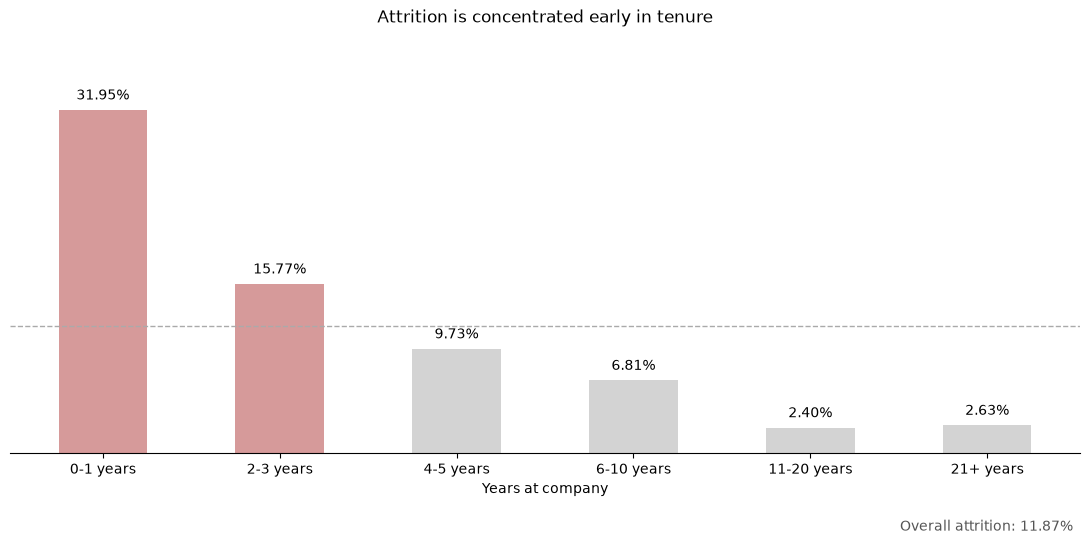

In [53]:
rate_chart(tenure_attrition["Yes"], "Attrition is concentrated early in tenure", "Years at company", "tenure_attrition.png")

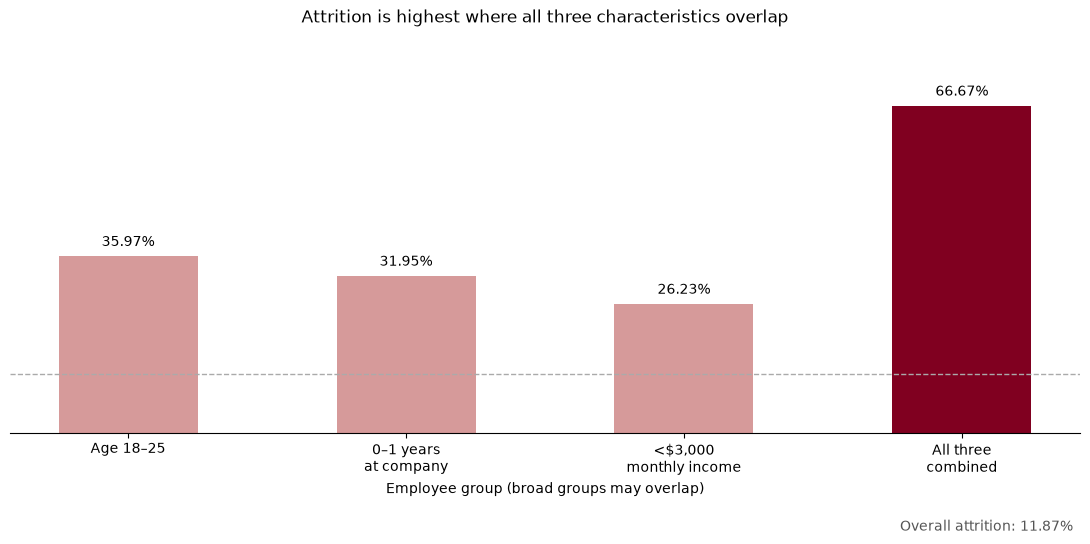

In [54]:
overlap_values = broad_segments["Attrition (%)"].copy()
overlap_values.index = ["Age 18–25", "0–1 years\nat company", "<$3,000\nmonthly income", "All three\ncombined"]
rate_chart(overlap_values, "Attrition is highest where all three characteristics overlap", "Employee group (broad groups may overlap)", "high_risk_factors_combined.png", ["#D69A9A"] * 3 + ["#800020"])

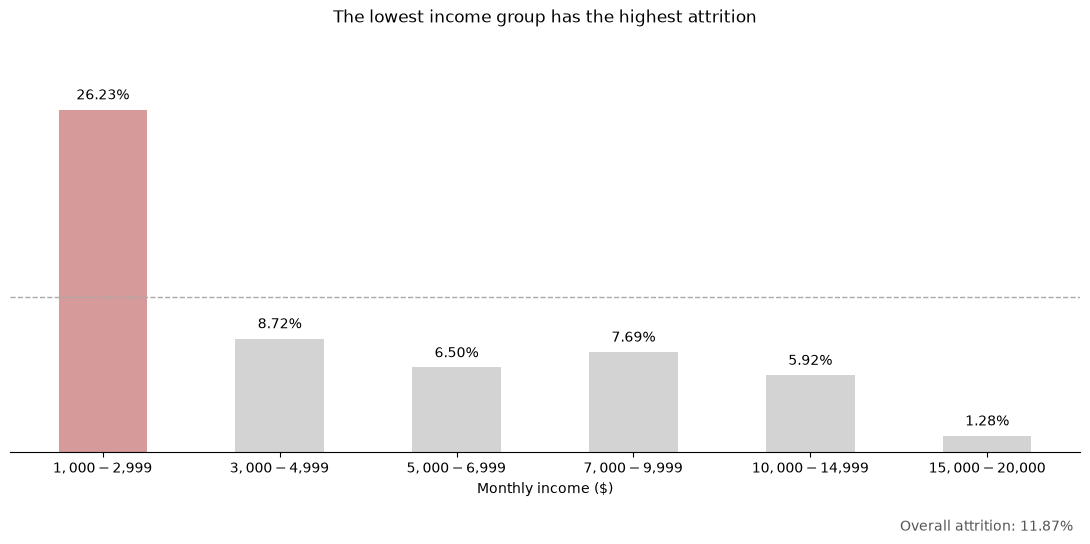

In [55]:
rate_chart(income_attrition["Yes"], "The lowest income group has the highest attrition", "Monthly income ($)", "income_attrition.png")

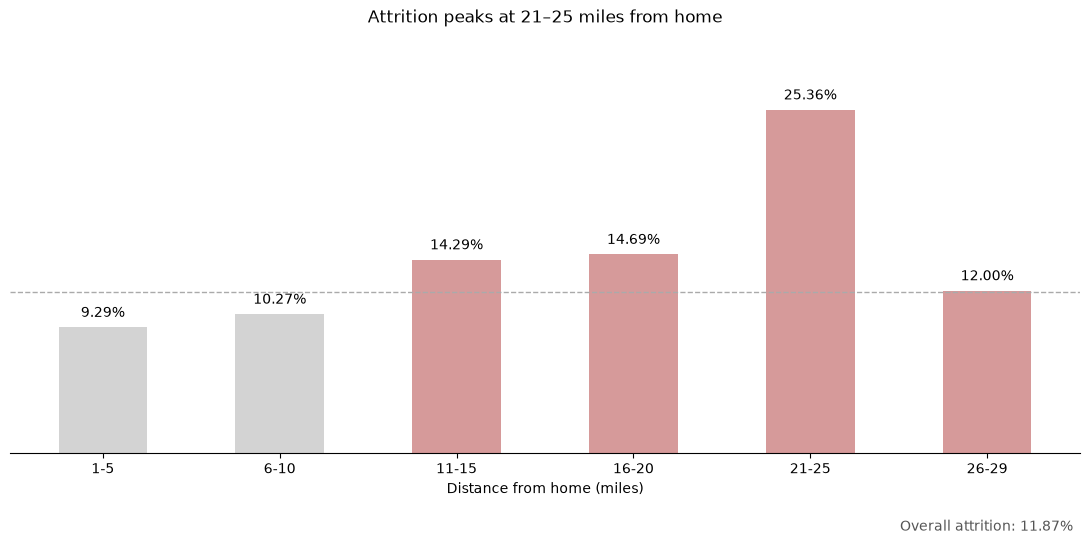

In [56]:
rate_chart(distance_attrition["Yes"], "Attrition peaks at 21–25 miles from home", "Distance from home (miles)", "distance_attrition.png")

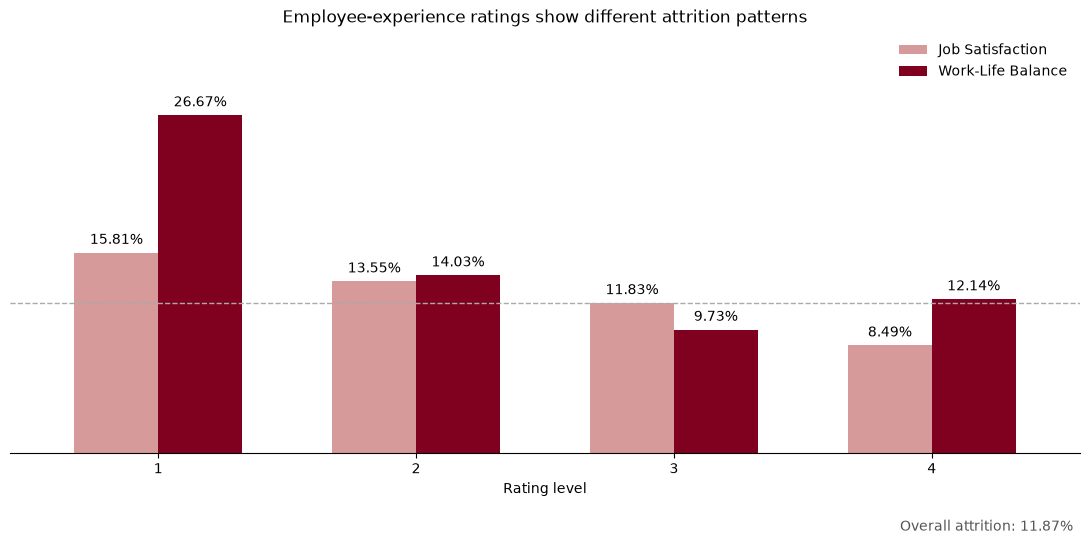

In [57]:
experience = pd.DataFrame({
    "Job Satisfaction": jobsatisfaction_attrition["Yes"],
    "Work-Life Balance": worklife_attrition["Yes"],
})
fig, ax = plt.subplots(figsize=(11, 5.5))
experience.plot.bar(ax=ax, color=["#D69A9A", "#800020"], width=0.65, rot=0)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2f%%", padding=4, fontsize=10)
ax.set(title="Employee-experience ratings show different attrition patterns", xlabel="Rating level", ylim=(0, experience.max().max() * 1.25))
ax.yaxis.set_visible(False)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.axhline(overall_rate_pct, color="#AAAAAA", linestyle="--", linewidth=1)
ax.legend(frameon=False, loc="upper right")
fig.text(0.98, 0.025, f"Overall attrition: {overall_rate_pct:.2f}%", ha="right", color="#555555")
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(figure_dir / "satisfaction_worklife_attrition.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

## 16. Conclusions, recommendations and limitations

- **Prioritize early-tenure support:** structured onboarding, 30/60/90-day check-ins and manager support, based on 31.95% attrition in the first tenure group.
- **Review lower-income roles:** assess pay competitiveness and advancement opportunities, especially where risk characteristics overlap.
- **Investigate employee experience:** monitor satisfaction and work-life balance; explore workload, scheduling, manager conversations and commute flexibility.

The combined segment represents 2.86% of employees and 16.08% of departures. The 66.67% rate is a useful descriptive finding but comes from only 48 employees. No causal inference, intervention-effect estimate or predictive model is established. The dataset has no confirmed observation period, so these rates should not be described as annual turnover. Source distance units follow the project's interpretation as miles.

### Power BI relationship
Power BI imported employee-level data and independently rebuilt the KPI measures with DAX (`COUNTROWS`, `CALCULATE`, `DIVIDE`). Python established the analysis and validation numbers; the Power BI cards do not read precomputed Python KPI totals.

## Reconciliation checks
These checks verify the key reported values against the supplied dataset, including bin coverage and the six Power BI chart series. A different dataset may legitimately fail these project-specific checks.

In [58]:
assert len(df) == 1676 and departures == 199
assert len(high_risk_group) == 48 and len(high_risk_attritioners) == 32
assert round(overall_rate_pct, 2) == 11.87
assert round(high_risk_attrition_rate, 2) == 66.67
assert round(high_risk_departure_share, 2) == 16.08
for column in ["AgeGroup", "TenureGroup", "IncomeGroup", "DistanceGroup", "CurrentRoleGroup", "PromotionGroup"]:
    assert df[column].notna().all(), f"Unbinned values in {column}"
expected_series = [
    (age_attrition, [35.97, 15.71, 4.53, 4.20, 9.80]),
    (tenure_attrition, [31.95, 15.77, 9.73, 6.81, 2.40, 2.63]),
    (income_attrition, [26.23, 8.72, 6.50, 7.69, 5.92, 1.28]),
    (distance_attrition, [9.29, 10.27, 14.29, 14.69, 25.36, 12.00]),
    (jobsatisfaction_attrition, [15.81, 13.55, 11.83, 8.49]),
    (worklife_attrition, [26.67, 14.03, 9.73, 12.14]),
]
for table, expected in expected_series:
    assert np.allclose(table["Yes"].round(2).to_numpy(), expected)
assert isolated_segments["Employees"].tolist() == [49, 105, 270, 48]
assert isolated_segments["Departures"].tolist() == [7, 15, 46, 32]
print("All population, KPI, bin coverage and chart reconciliation checks passed.")

All population, KPI, bin coverage and chart reconciliation checks passed.


## Appendix: formatting without changing values
This learning example was used for the LinkedIn Python series. The analysis table remains numeric. Creating a separate string-formatted table demonstrates why display formatting and changing data types are different.

In [59]:
display(age_attrition.dtypes.to_frame("Numeric table"))
age_attrition_text = age_attrition.map(lambda x: f"{x:.2f}%")
display(age_attrition_text.dtypes.to_frame("Text-formatted copy"))
display(age_attrition.style.format("{:.2f}%"))
print(f"Highest age-group attrition: {age_attrition['Yes'].max():.2f}%")

,Numeric table
Attrition,
No,float64
Yes,float64


,Text-formatted copy
Attrition,
No,str
Yes,str


Attrition,No,Yes
AgeGroup,,
18-25,64.03%,35.97%
26-35,84.29%,15.71%
36-45,95.47%,4.53%
46-55,95.80%,4.20%
56-60,90.20%,9.80%


Highest age-group attrition: 35.97%
